<p style="color:#824AE8;font-family:Ubuntu Light;font-size:140%">DATA SCIENCE IN CHEMISTRY</p>

# Substructure Search using RDKit

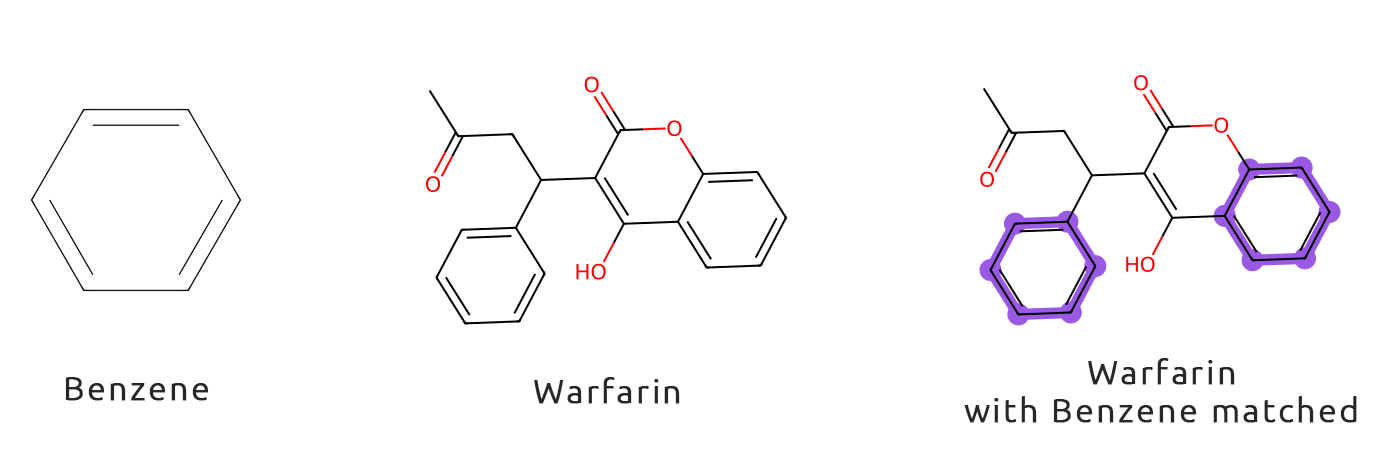

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw

In [2]:
caffeine = Chem.MolFromSmiles('CN1C=NC2=C1C(=O)N(C(=O)N2C)C')
carbonyl = Chem.MolFromSmiles('C=O')
methyl = Chem.MolFromSmiles('C')

In [3]:
matches = caffeine.GetSubstructMatches(carbonyl)
matches

((6, 7), (9, 10))

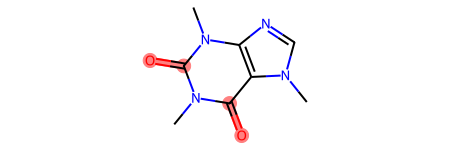

In [4]:
caffeine

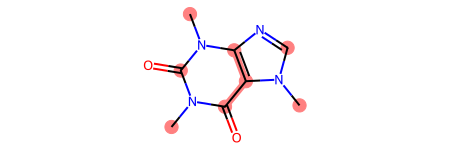

In [5]:
matches = caffeine.GetSubstructMatches(methyl)
caffeine

### SMARTS Strings

### To check your SMARTS use: https://smarts.plus

In [6]:
methyl_pattern = Chem.MolFromSmarts("[CH3]")

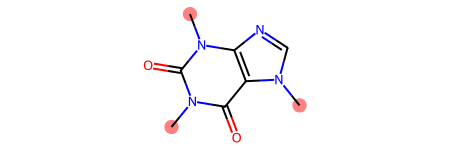

In [7]:
matches = caffeine.GetSubstructMatches(methyl_pattern)
caffeine

______________________________________________________________

### Substructure Search in a Dataset

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("pubchem_molecules.csv")
df

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N


In [10]:
benzene = "c1ccccc1"
benzene_pattern = Chem.MolFromSmiles(benzene)

In [12]:
def has_benzene(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol.HasSubstructMatch(benzene_pattern)

In [13]:
df["Has_Benzene"] = df["SMILES"].apply(has_benzene)

In [14]:
df

,Unnamed: 0,Name,CID,IUPAC_Name,Molecular_Formula,Molecular_Weight,SMILES,InChI,InChIKey,Has_Benzene
0,0,methane,297,methane,CH4,16.043,C,InChI=1S/CH4/h1H4,VNWKTOKETHGBQD-UHFFFAOYSA-N,False
1,1,2-acetyloxybenzoic acid,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,True
2,2,pentanal,8063,pentanal,C5H10O,86.130,CCCCC=O,"InChI=1S/C5H10O/c1-2-3-4-5-6/h5H,2-4H2,1H3",HGBOYTHUEUWSSQ-UHFFFAOYSA-N,False
3,3,aspirin,2244,2-acetyloxybenzoic acid,C9H8O4,180.160,CC(=O)OC1=CC=CC=C1C(=O)O,InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)...,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,True
4,4,ibuprofen,3672,2-[4-(2-methylpropyl)phenyl]propanoic acid,C13H18O2,206.280,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,InChI=1S/C13H18O2/c1-9(2)8-11-4-6-12(7-5-11)10...,HEFNNWSXXWATRW-UHFFFAOYSA-N,True
5,5,paracetamol,1983,N-(4-hydroxyphenyl)acetamide,C8H9NO2,151.160,CC(=O)NC1=CC=C(C=C1)O,InChI=1S/C8H9NO2/c1-6(10)9-7-2-4-8(11)5-3-7/h2...,RZVAJINKPMORJF-UHFFFAOYSA-N,True
6,6,naproxen,156391,(2S)-2-(6-methoxynaphthalen-2-yl)propanoic acid,C14H14O3,230.260,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)O,InChI=1S/C14H14O3/c1-9(14(15)16)10-3-4-12-8-13...,CMWTZPSULFXXJA-VIFPVBQESA-N,True
7,7,diclofenac,3033,"2-[2-(2,6-dichloroanilino)phenyl]acetic acid",C14H11Cl2NO2,296.100,C1=CC=C(C(=C1)CC(=O)O)NC2=C(C=CC=C2Cl)Cl,InChI=1S/C14H11Cl2NO2/c15-10-5-3-6-11(16)14(10...,DCOPUUMXTXDBNB-UHFFFAOYSA-N,True
8,8,codeine,5284371,"(4R,4aR,7S,7aR,12bS)-9-methoxy-3-methyl-2,4,4a...",C18H21NO3,299.400,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)OC)O[C...,InChI=1S/C18H21NO3/c1-19-8-7-18-11-4-5-13(20)1...,OROGSEYTTFOCAN-DNJOTXNNSA-N,True
9,9,ethanol,702,ethanol,C2H6O,46.070,CCO,"InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3",LFQSCWFLJHTTHZ-UHFFFAOYSA-N,False


## Maximum Common Substructure

### Chem.rdFMCS

In [15]:
from rdkit.Chem import rdFMCS

In [16]:
sdf = Chem.ForwardSDMolSupplier("ee61_molecules.sdf")
mols = list(sdf)
mols

In [17]:
mcs = rdFMCS.FindMCS(mols)

In [18]:
pattern = mcs.smartsString
print(pattern)

[#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]-[#6]-[#6]


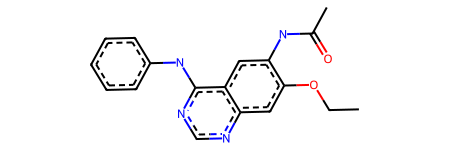

In [19]:
Chem.MolFromSmarts(pattern)

In [20]:
print(f"Maximum Common Substructure contains {mcs.numAtoms} atoms and {mcs.numBonds} Bonds.")

Maximum Common Substructure contains 24 atoms and 26 Bonds.


C:\Users\moham\anaconda3\envs\datasciencechemistry\Lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


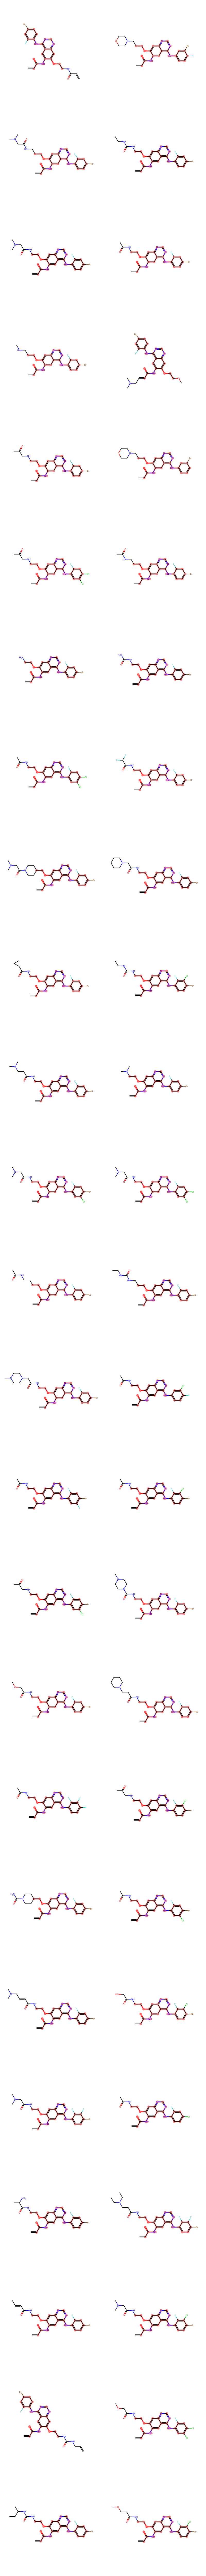

In [21]:
pattern_mol = Chem.MolFromSmarts(pattern)
matching = [molecule.GetSubstructMatch(pattern_mol) for molecule in mols]

Draw.MolsToGridImage(mols,
                    molsPerRow = 2,
                    highlightAtomLists = matching,
                    subImgSize = (400, 400))